# Native certification, retention and tolerance

This notebook rebuilds the paper's native validation counts from paired means and covariance, checks the saved certificates, and draws the registered-query and tolerance panels. The shared implementation is `wowfs.reproduction.science`; no simulator is launched.

The unit is a registered catalogue. The 128 targets within 16 catalogues are correlated. Expanded menus, projected tasks and tolerance levels reuse the same observations. UNKNOWN remains unresolved.

Run `make prepare` first to configure portable inputs. Analysis files are generated in the external work directory. Executed notebook outputs are also committed so figures and tables are visible on GitHub.


In [1]:
from pathlib import Path
import sys

roots = (Path.cwd(), *Path.cwd().parents)
ROOT = next((p for p in roots if (p / "pyproject.toml").is_file() and (p / "src/wowfs").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Run this notebook from the repository or one of its subdirectories.")
sys.path.insert(0, str(ROOT / "src"))
from wowfs.reproduction.context import get_context
ctx = get_context()

import json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
FIGURES = ctx.output / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def table(rows, columns):
    text = "| " + " | ".join(columns) + " |\n| " + " | ".join(["---"] * len(columns)) + " |\n"
    for row in rows:
        text += "| " + " | ".join(str(row.get(k, "")) for k in columns) + " |\n"
    display(Markdown(text))

print("Input bundle:", ctx.bundle)
print("Generated outputs:", ctx.output)


Input bundle: /work/Users/leiyo/wow-forever-sustainability-work/inputs/paper-reproduction/review/review-v2
Generated outputs: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928


## Recompute the simultaneous event

For each catalogue the covered contrast family has size $Q(M+2M^2)$ and uses
$t_{N-1}^{-1}(1-\alpha/(2Q(M+2M^2)))$, with $\alpha=0.0025$. Full paired covariance includes uncertainty in the original history reference. This is the existing fixed-N paired-t approximation, not a distribution-free coverage guarantee.

The replay exhausts all allowed helper supersets. A lower-endpoint witness establishes YES; no upper-endpoint completion establishes NO. All other cases retain UNKNOWN. Secondary tolerances propagate the original event; they do not spend fresh alpha or recompute a new t direction.


In [2]:
from wowfs.reproduction.science import run_certification_checks

# A completed identical run is hash-verified and reused. A changed source/input
# requires a fresh output directory; failed invocations remain in failures/.
result = run_certification_checks(ctx, resume=True)
panel = result["native_panel"]
assert result["status"] == "PASS"
print(json.dumps({k: panel[k] for k in ("catalogues", "registered_queries", "confidence_counts", "retention_essential")}, indent=2))


{
  "catalogues": 16,
  "registered_queries": 128,
  "confidence_counts": {
    "NO": 76,
    "UNKNOWN": 10,
    "YES": 42
  },
  "retention_essential": 69
}


## Registered native outcomes

The table and figure below use recomputed certificates for the eight preregistered targets in each base catalogue. These denominators differ from the full target powerset audited in notebook 04.


| world_id | class | faction | queries | YES | NO | UNKNOWN |
| --- | --- | --- | --- | --- | --- | --- |
| co_warrior_weapon_skill__validation_00 | Warrior | Alliance | 8 | 0 | 7 | 1 |
| co_warrior_weapon_skill__validation_01 | Warrior | Horde | 8 | 3 | 4 | 1 |
| co_warrior_weapon_skill__validation_02 | Warrior | Alliance | 8 | 0 | 4 | 4 |
| co_warrior_weapon_skill__validation_03 | Warrior | Horde | 8 | 0 | 8 | 0 |
| co_paladin_seal_twisting__validation_00 | Paladin | Alliance | 8 | 1 | 6 | 1 |
| co_paladin_seal_twisting__validation_01 | Paladin | Horde | 8 | 4 | 4 | 0 |
| co_paladin_seal_twisting__validation_02 | Paladin | Alliance | 8 | 0 | 8 | 0 |
| co_paladin_seal_twisting__validation_03 | Paladin | Horde | 8 | 3 | 5 | 0 |
| co_mage_timed_resources__validation_00 | Mage | Alliance | 8 | 6 | 1 | 1 |
| co_mage_timed_resources__validation_01 | Mage | Horde | 8 | 4 | 3 | 1 |
| co_mage_timed_resources__validation_02 | Mage | Alliance | 8 | 4 | 3 | 1 |
| co_mage_timed_resources__validation_03 | Mage | Horde | 8 | 5 | 3 | 0 |
| co_druid_passive_resources__validation_00 | Druid | Alliance | 8 | 0 | 8 | 0 |
| co_druid_passive_resources__validation_01 | Druid | Horde | 8 | 5 | 3 | 0 |
| co_druid_passive_resources__validation_02 | Druid | Alliance | 8 | 3 | 5 | 0 |
| co_druid_passive_resources__validation_03 | Druid | Horde | 8 | 4 | 4 | 0 |


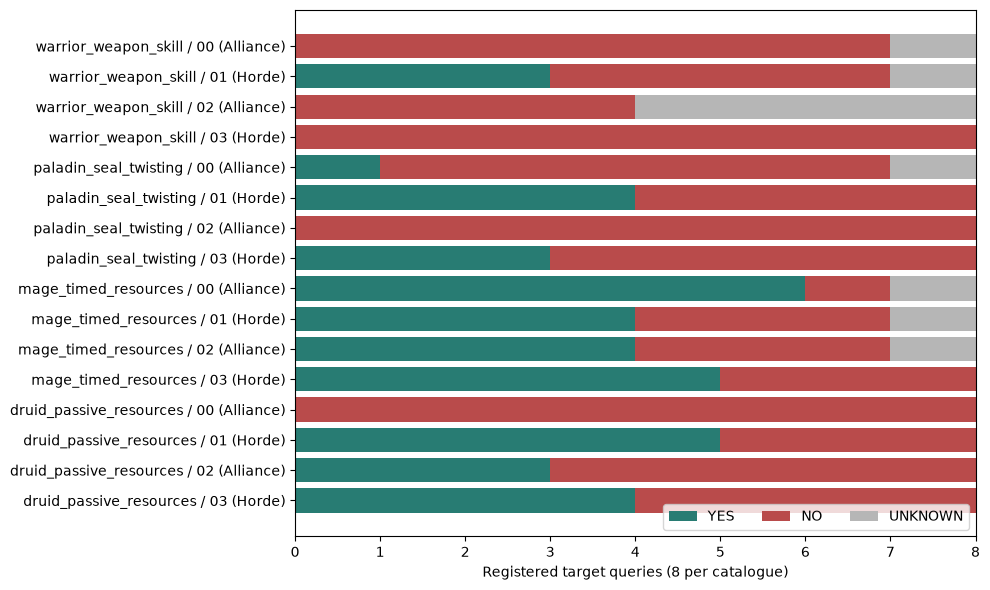

In [3]:
rows = panel["catalogue_rows"]
table(rows, ["world_id", "class", "faction", "queries", "YES", "NO", "UNKNOWN"])
colors = {"YES": "#287c73", "NO": "#b94b4b", "UNKNOWN": "#b6b6b6"}
fig, ax = plt.subplots(figsize=(10, 6))
left = [0] * len(rows)
labels = [r["world_id"].replace("co_", "").replace("__validation_", " / ") + " (" + r["faction"] + ")" for r in rows]
for status in ("YES", "NO", "UNKNOWN"):
    values = [r[status] for r in rows]
    ax.barh(labels, values, left=left, label=status, color=colors[status])
    left = [a + b for a, b in zip(left, values)]
ax.set(xlabel="Registered target queries (8 per catalogue)", xlim=(0, 8))
ax.invert_yaxis()
ax.legend(ncols=3, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "native_registered_outcomes.pdf", bbox_inches="tight")
plt.show()


## Retention ablation

Retention-essential means a certified NO with all obligations, together with a certified YES when retention is disabled. The power, gain, target and physical domain stay fixed. Legacy-only sufficient and legacy-necessary labels may overlap; they must not be added together.


In [4]:
labels = panel["obligation_labels"]
retention_rows = [
    {"quantity": "Certified base NO", "queries": panel["confidence_counts"]["NO"]},
    {"quantity": "Retention-essential NO", "queries": panel["retention_essential"]},
    {"quantity": "Legacy obligations alone suffice", "queries": labels["legacy_alone_sufficient"]},
    {"quantity": "Dropping legacy obligations restores YES", "queries": labels["legacy_necessary_for_obstruction"]},
]
table(retention_rows, ["quantity", "queries"])
assert panel["confidence_counts"] == {"YES": 42, "NO": 76, "UNKNOWN": 10}
assert panel["retention_essential"] == 69


| quantity | queries |
| --- | --- |
| Certified base NO | 76 |
| Retention-essential NO | 69 |
| Legacy obligations alone suffice | 42 |
| Dropping legacy obligations restores YES | 28 |


## Tolerance sensitivity

All four rows use the same 128 base targets. The tolerance is normative; these are dependent reanalyses, not additional independent catalogue samples.


| tolerance | YES | NO | UNKNOWN |
| --- | --- | --- | --- |
| 1/200 | 21 | 92 | 15 |
| 1/100 | 42 | 76 | 10 |
| 1/50 | 68 | 50 | 10 |
| 1/20 | 106 | 14 | 8 |


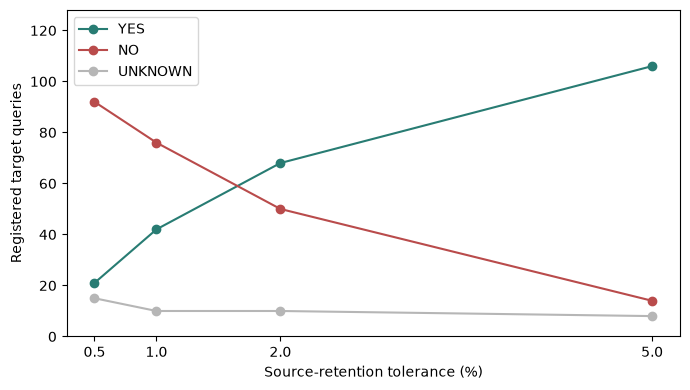

In [5]:
from fractions import Fraction
rows = panel["tolerance_rows"]
table(rows, ["tolerance", "YES", "NO", "UNKNOWN"])
x = [100 * float(Fraction(r["tolerance"])) for r in rows]
fig, ax = plt.subplots(figsize=(7, 4))
for status in ("YES", "NO", "UNKNOWN"):
    ax.plot(x, [r[status] for r in rows], "o-", label=status, color=colors[status])
ax.set(xlabel="Source-retention tolerance (%)", ylabel="Registered target queries", ylim=(0, 128), xticks=x)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "native_tolerance_panel.pdf", bbox_inches="tight")
plt.show()


## Benchmark integrity and saved measurements

The checker also recomputes metrics and common-prefix counts from the full compact per-query receipts. Historical wall-clock durations remain measurements from the original hardware. Notebook 02 presents the paper's solver runtime table; rerunning solvers is a separate workflow.


In [6]:
print(json.dumps(result["benchmark_recheck"], indent=2))
print("Full replay receipt:", ctx.output / "science/certification/RUN_RECEIPT.json")
assert result["new_native_calls"] == 0


{
  "status": "PASS",
  "decision_attempts": 1254,
  "query_records": 495454,
  "prefix_records": 972,
  "raw_job_directories_required": false,
  "floating_summary_recheck_tolerance": {
    "relative": 1e-10,
    "absolute": 1e-12
  },
  "report_source_revision_matches": true,
  "counts_statuses_and_memberships_checked_exactly": true
}
Full replay receipt: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928/science/certification/RUN_RECEIPT.json
